# CLIP model X ModelvsBaby Dataset

Import Model

In [1]:
from transformers import CLIPProcessor, CLIPModel
model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Import Dataset

In [2]:
!pip install --upgrade transformers

In [33]:
import os
import io
import zipfile
import requests

import pandas as pd
from io import BytesIO
from PIL import Image
import numpy as np

import torch
from transformers import CLIPModel, CLIPProcessor
from collections import defaultdict
import math

import warnings
warnings.filterwarnings('ignore')

In [3]:
print("Downloading dataset...")
url = "https://osf.io/download/ba4g2/"
response = requests.get(url)

In [5]:
print("Extracting files...")
with zipfile.ZipFile(BytesIO(response.content)) as zip_ref:
    zip_ref.extractall('modelvsbaby_data')

Extracting files...


In [5]:
def count_params(module):
    return sum(p.numel() for p in module.parameters())


def named_param_counts(model):
    counts = defaultdict(lambda: {'total':0, 'trainable':0})
    for name, p in model.named_parameters():
        prefix = name.split('.')[0]
        counts[prefix]['total'] += p.numel()
        if p.requires_grad:
            counts[prefix]['trainable'] += p.numel()
    return dict(counts)


def module_param_table(model, max_items=200):
    rows = []
    for name, module in model.named_modules():
        if name == '':
            continue
        param_count = count_params(module)
        if param_count == 0:
            continue
        rows.append((name, module.__class__.__name__, param_count))
    rows.sort(key=lambda x: -x[2])
    return rows[:max_items]


def human(n):
    for unit in ['','K','M','B']:
        if abs(n) < 1000.0:
            return f"{n:.2f}{unit}"
        n /= 1000.0
    return f"{n:.2f}T"

In [6]:
# Load CLIP model
model_name = 'openai/clip-vit-large-patch14'
print('Loading model ->', model_name)
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)
model.eval()

Loading model -> openai/clip-vit-large-patch14


CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 768)
      (position_embedding): Embedding(77, 768)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05,

In [7]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params} ({human(total_params)})')
print(f'Trainable parameters: {trainable_params} ({human(trainable_params)})')

Total parameters: 427616513 (427.62M)
Trainable parameters: 427616513 (427.62M)


In [8]:
try:
    cfg = model.config
    print('\nModel config:')
    for k in ['vision_model', 'text_model', 'projection_dim', 'image_embed_dim', 'text_embed_dim']:
        if hasattr(cfg, k):
            print(f' - {k}:', getattr(cfg, k))
    print('\nFull config keys:', list(cfg.to_dict().keys())[:40])
except Exception as e:
    print('Could not extract config details:', e)


Model config:
 - projection_dim: 768

Full config keys: ['return_dict', 'output_hidden_states', 'torchscript', 'dtype', 'pruned_heads', 'tie_word_embeddings', 'chunk_size_feed_forward', 'is_encoder_decoder', 'is_decoder', 'cross_attention_hidden_size', 'add_cross_attention', 'tie_encoder_decoder', 'architectures', 'finetuning_task', 'id2label', 'label2id', 'task_specific_params', 'problem_type', 'tokenizer_class', 'prefix', 'bos_token_id', 'pad_token_id', 'eos_token_id', 'sep_token_id', 'decoder_start_token_id', 'max_length', 'min_length', 'do_sample', 'early_stopping', 'num_beams', 'temperature', 'top_k', 'top_p', 'typical_p', 'repetition_penalty', 'length_penalty', 'no_repeat_ngram_size', 'encoder_no_repeat_ngram_size', 'bad_words_ids', 'num_return_sequences']


In [9]:
# Per-module parameter breakdown (top-level prefixes)
print('\nTop-level module parameter counts:')
counts = named_param_counts(model)
items = sorted(counts.items(), key=lambda x: -x[1]['total'])
for prefix, c in items:
    print(f"{prefix:30s} -> total: {human(c['total']):8s}  trainable: {human(c['trainable']):8s}")


Top-level module parameter counts:
vision_model                   -> total: 303.18M   trainable: 303.18M 
text_model                     -> total: 123.06M   trainable: 123.06M 
visual_projection              -> total: 786.43K   trainable: 786.43K 
text_projection                -> total: 589.82K   trainable: 589.82K 
logit_scale                    -> total: 1.00      trainable: 1.00    


In [10]:
# Detailed module table
print('\nDetailed module table (largest modules):')
rows = module_param_table(model, max_items=200)
for name, cls, cnt in rows[:40]:
    print(f"{name:60s} | {cls:20s} | {human(cnt):8s} params")


Detailed module table (largest modules):
vision_model                                                 | CLIPVisionTransformer | 303.18M  params
vision_model.encoder                                         | CLIPEncoder          | 302.31M  params
vision_model.encoder.layers                                  | ModuleList           | 302.31M  params
text_model                                                   | CLIPTextTransformer  | 123.06M  params
text_model.encoder                                           | CLIPEncoder          | 85.05M   params
text_model.encoder.layers                                    | ModuleList           | 85.05M   params
text_model.embeddings                                        | CLIPTextEmbeddings   | 38.00M   params
text_model.embeddings.token_embedding                        | Embedding            | 37.95M   params
vision_model.encoder.layers.0                                | CLIPEncoderLayer     | 12.60M   params
vision_model.encoder.layers.1          

In [18]:
# Inspect ViT (vision) transformer blocks more closely
print('\nLooking inside the vision transformer (if available)...')
vision = None
if hasattr(model, 'vision_model'):
    vision = model.vision_model
elif hasattr(model, 'vision_model.encoder'):
    vision = model.vision_model.encoder

if vision is None:
    for name, module in model.named_modules():
        if 'vision' in name and 'transformer' in name:
            vision = module
            break

if vision is not None:
    try:
        print('\nVision model class:', vision.__class__.__name__)
        v_counts = named_param_counts(vision)
        items = sorted(v_counts.items(), key=lambda x: -x[1]['total'])
        for prefix, c in items:
            print(f"{prefix:30s} -> total: {human(c['total']):8s}")

        blocks = None
        for candidate in ['encoder.layer', 'encoder.layers', 'encoder.block', 'transformer.encoder.layer']:
            try:
                blocks = eval('vision.' + candidate)
                break
            except Exception:
                pass
        if blocks is not None:
            num_blocks = len(blocks)
            print(f"\nFound {num_blocks} transformer blocks.")
            # first block
            first = blocks[0]
            print('\nFirst block class:', first.__class__.__name__)
            print('First block param breakdown:')
            for name, module in first.named_children():
                pcount = count_params(module)
                print(f"  {name:30s} | {module.__class__.__name__:20s} | {human(pcount):8s}")

            # Q/K/V matrices and MLP
            qkv_found = []
            for n, m in first.named_modules():
                lname = n.lower()
                if 'qkv' in lname or 'q' in lname and ('k' in lname or 'v' in lname) or 'attention' in lname:
                    qkv_found.append((n, m))
            if qkv_found:
                print('\nCandidate Q/K/V / attention submodules (first block):')
                for n, m in qkv_found[:10]:
                    print(' -', n, '|', m.__class__.__name__, '| params', human(count_params(m)))
            else:
                print('\n')

    except Exception as e:
        print('Error inspecting vision model:', e)
else:
    print('Vision model not found in checkpoint under common names.')


Looking inside the vision transformer (if available)...

Vision model class: CLIPVisionTransformer
encoder                        -> total: 302.31M 
embeddings                     -> total: 866.30K 
pre_layrnorm                   -> total: 2.05K   
post_layernorm                 -> total: 2.05K   

Found 24 transformer blocks.

First block class: CLIPEncoderLayer
First block param breakdown:
  self_attn                      | CLIPAttention        | 4.20M   
  layer_norm1                    | LayerNorm            | 2.05K   
  mlp                            | CLIPMLP              | 8.39M   
  layer_norm2                    | LayerNorm            | 2.05K   




In [12]:
# Inspect text transformer blocks
print('\nInspecting text transformer (if available)...')
text = getattr(model, 'text_model', None)
if text is None:
    for n, module in model.named_modules():
        if 'text' in n and 'transformer' in n:
            text = module
            break

if text is not None:
    try:
        print('Text model class:', text.__class__.__name__)
        t_counts = named_param_counts(text)
        items = sorted(t_counts.items(), key=lambda x: -x[1]['total'])
        for prefix, c in items:
            print(f"{prefix:30s} -> total: {human(c['total']):8s}")

        # Transformer blocks
        blocks = None
        for candidate in ['encoder.layer', 'encoder.layers', 'transformer.encoder.layer', 'transformer.resblocks']:
            try:
                blocks = eval('text.' + candidate)
                break
            except Exception:
                pass
        if blocks is not None:
            print('\nFound', len(blocks), 'text blocks. First block breakdown:')
            first = blocks[0]
            for name, module in first.named_children():
                print(f"  {name:30s} | {module.__class__.__name__:20s} | {human(count_params(module)):8s}")
    except Exception as e:
        print('Error inspecting text model:', e)
else:
    print('Text model not found in checkpoint under common names.')


Inspecting text transformer (if available)...
Text model class: CLIPTextTransformer
encoder                        -> total: 85.05M  
embeddings                     -> total: 38.00M  
final_layer_norm               -> total: 1.54K   

Found 12 text blocks. First block breakdown:
  self_attn                      | CLIPAttention        | 2.36M   
  layer_norm1                    | LayerNorm            | 1.54K   
  mlp                            | CLIPMLP              | 4.72M   
  layer_norm2                    | LayerNorm            | 1.54K   


In [16]:
# Explicit parameter arithmetic for one transformer block (vision) when shapes are available
print('\nExplicit parameter arithmetic for first vision transformer block (if shapes available):')
try:
    # Find qkv linear and mlp fc layers by name and print shapes
    if vision is not None and blocks is not None:
        first = blocks[0]
        for n, m in first.named_modules():
            if hasattr(m, 'weight'):
                w = m.weight
                print(f"Module: {n:40s} | class: {m.__class__.__name__:20s} | weight shape: {tuple(w.shape)} | params: {human(w.numel())}")
except Exception as e:
    print('Could not compute explicit arithmetic:', e)


Explicit parameter arithmetic for first vision transformer block (if shapes available):
Module: self_attn.k_proj                         | class: Linear               | weight shape: (768, 768) | params: 589.82K
Module: self_attn.v_proj                         | class: Linear               | weight shape: (768, 768) | params: 589.82K
Module: self_attn.q_proj                         | class: Linear               | weight shape: (768, 768) | params: 589.82K
Module: self_attn.out_proj                       | class: Linear               | weight shape: (768, 768) | params: 589.82K
Module: layer_norm1                              | class: LayerNorm            | weight shape: (768,) | params: 768.00
Module: mlp.fc1                                  | class: Linear               | weight shape: (3072, 768) | params: 2.36M
Module: mlp.fc2                                  | class: Linear               | weight shape: (768, 3072) | params: 2.36M
Module: layer_norm2                              |

In [15]:
# Encode a dummy image + text to get embedding shapes
print('\nRunning a quick dummy forward pass to show shapes...')
from PIL import Image
import numpy as np

# Create a dummy RGB image (224x224) - CLIP ViT-L/14 uses larger resolution but processor will handle resizing
dummy_img = Image.fromarray((np.random.rand(224,224,3)*255).astype('uint8'))
inputs = processor(text=["a photo of a cat"], images=dummy_img, return_tensors='pt')
with torch.no_grad():
    out = model(**inputs)

# CLIPModel returns: image_embeds, text_embeds, logits_per_image, logits_per_text
for k, v in out.items():
    try:
        print(f"{k:20s} -> type: {type(v)}, shape: {tuple(v.shape) if hasattr(v, 'shape') else 'scalar'}")
    except Exception:
        print(k, '->', type(v))


Running a quick dummy forward pass to show shapes...
logits_per_image     -> type: <class 'torch.Tensor'>, shape: (1, 1)
logits_per_text      -> type: <class 'torch.Tensor'>, shape: (1, 1)
text_embeds          -> type: <class 'torch.Tensor'>, shape: (1, 768)
image_embeds         -> type: <class 'torch.Tensor'>, shape: (1, 768)
text_model_output    -> type: <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>, shape: scalar
vision_model_output  -> type: <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>, shape: scalar


In [20]:
import os
from pathlib import Path
from tqdm import tqdm
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import json

Quick parameter check

In [21]:
MODEL_NAME = "openai/clip-vit-large-patch14"
DATA_ROOT = Path("/content/modelvsbaby_data/image_files/v0")
LABELS = ["airplane","car","chair","cup","dog","donkey","duck","hat"]
CONDITIONS = ['realistic', 'features', 'blurred', 'geons', 'silhouettes']
BATCH_IMAGE = 8
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_RESULTS = True
OUT_DIR = Path("/content/modelvsbaby_eval_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [22]:
print("Loading CLIP:", MODEL_NAME)
model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

Loading CLIP: openai/clip-vit-large-patch14


In [23]:
text_inputs = [f"a photo of a {lbl}" for lbl in LABELS]
with torch.no_grad():
    text_tokens = processor(text=text_inputs, return_tensors="pt", padding=True).to(DEVICE)
    text_outputs = model.get_text_features(**text_tokens)  # shape: (8, dim)
    text_embeddings = text_outputs / text_outputs.norm(p=2, dim=-1, keepdim=True)

In [24]:
def gather_images_for_condition(cond_path):
    records = []  # list of (img_path, true_label)
    if not cond_path.exists():
        return records
    # check subdirs for category names
    subdirs = [p for p in cond_path.iterdir() if p.is_dir()]
    if subdirs:
        # assume each subdir is a category folder
        for cat_dir in subdirs:
            cat_name = cat_dir.name.lower()
            if cat_name not in LABELS:
                # try to match by partial
                matches = [lbl for lbl in LABELS if lbl in cat_name]
                label = matches[0] if matches else None
            else:
                label = cat_name
            if label is None:
                continue
            for img in cat_dir.iterdir():
                if img.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tiff"]:
                    records.append((img, label))
    else:
        # no subdirs: try to parse filenames like 'airplane_01.png' or 'airplane-01.png'
        for img in cond_path.iterdir():
            if not img.is_file():
                continue
            if img.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp", ".tiff"]:
                continue
            name = img.stem.lower()
            found = None
            for lbl in LABELS:
                if name.startswith(lbl) or f"_{lbl}_" in name or f"-{lbl}-" in name or f"_{lbl}" in name or f"-{lbl}" in name:
                    found = lbl
                    break
            if found is None:
                # fallback: if only one label present in all filenames, skip
                continue
            records.append((img, found))
    return records

Evaluate per condition

Processing realistic: 100%|██████████| 41/41 [00:02<00:00, 17.88img/s]



Condition: realistic | N=41 | accuracy=1.0000


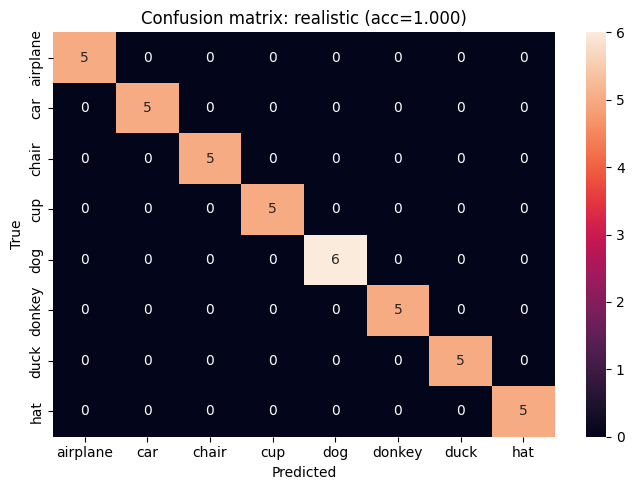

Processing features: 100%|██████████| 41/41 [00:03<00:00, 13.56img/s]



Condition: features | N=41 | accuracy=0.8293


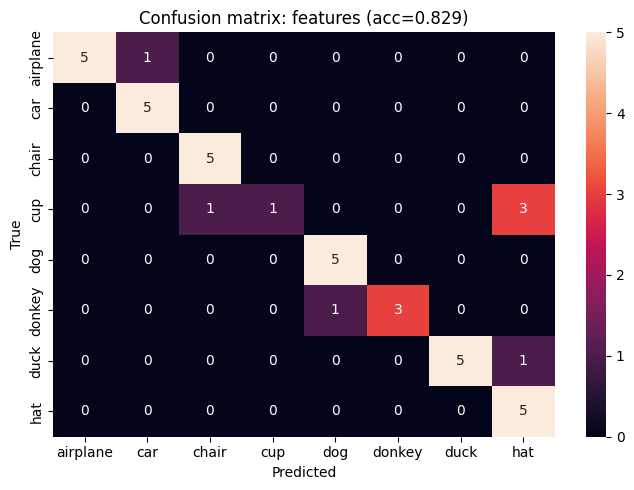

Processing blurred: 100%|██████████| 42/42 [00:03<00:00, 11.37img/s]



Condition: blurred | N=42 | accuracy=0.8333


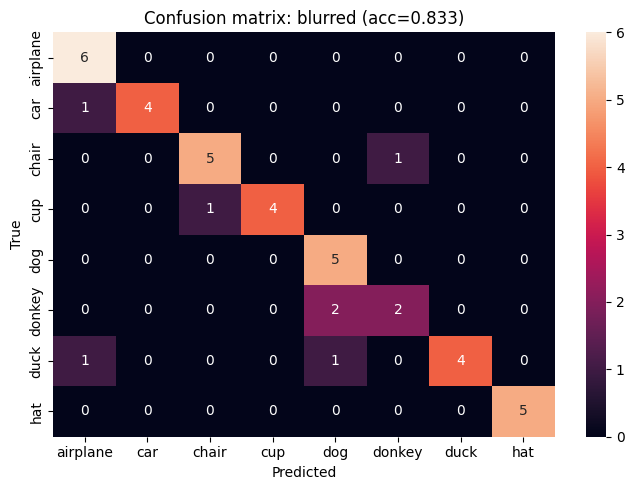

Processing geons: 100%|██████████| 59/59 [00:05<00:00, 10.01img/s]



Condition: geons | N=59 | accuracy=0.5254


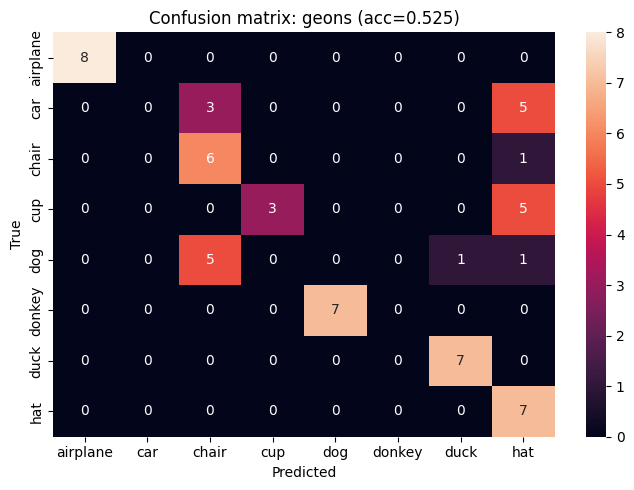

Processing silhouettes: 100%|██████████| 40/40 [00:03<00:00, 10.74img/s]



Condition: silhouettes | N=40 | accuracy=0.9500


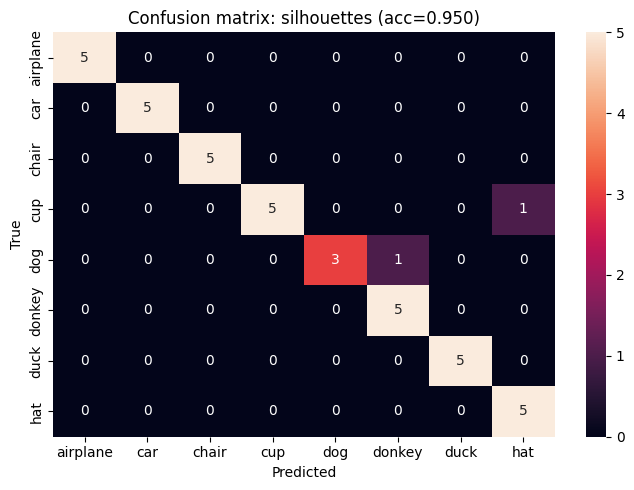

In [25]:
results = {}
for cond in CONDITIONS:
    cond_path = DATA_ROOT / cond
    imgs = gather_images_for_condition(cond_path)
    if len(imgs) == 0:
        print(f"[WARN] No images found for condition folder: {cond_path}")
        results[cond] = {"n": 0, "acc": None, "confusion": None}
        continue

    true_labels = []
    pred_labels = []

    batch = []
    batch_true = []
    for img_path, true_label in tqdm(imgs, desc=f"Processing {cond}", unit="img"):
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print("error loading", img_path, e)
            continue
        batch.append(img)
        batch_true.append(true_label)

        if len(batch) >= BATCH_IMAGE:
            inputs = processor(text=None, images=batch, return_tensors="pt", padding=True).to(DEVICE)
            with torch.no_grad():
                image_features = model.get_image_features(**inputs)
                image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)  # normalize
                # Cosine similarities: (N_images, 1, dim) dot (1, N_texts, dim) -> (N_images, N_texts)
                sims = image_features @ text_embeddings.t()
                preds = sims.argmax(dim=1).cpu().tolist()
            for i, true in enumerate(batch_true):
                true_labels.append(true)
                pred_labels.append(LABELS[preds[i]])
            batch = []
            batch_true = []

    # Final partial batch
    if len(batch) > 0:
        inputs = processor(text=None, images=batch, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad():
            image_features = model.get_image_features(**inputs)
            image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)
            sims = image_features @ text_embeddings.t()
            preds = sims.argmax(dim=1).cpu().tolist()
        for i, true in enumerate(batch_true):
            true_labels.append(true)
            pred_labels.append(LABELS[preds[i]])

    # build confusion matrix and accuracy
    y_true_idx = [LABELS.index(x) for x in true_labels]
    y_pred_idx = [LABELS.index(x) for x in pred_labels]
    cm = confusion_matrix(y_true_idx, y_pred_idx, labels=list(range(len(LABELS))))
    acc = accuracy_score(y_true_idx, y_pred_idx)

    results[cond] = {
        "n": len(true_labels),
        "accuracy": float(acc),
        "confusion_matrix": cm.tolist(),  # list for JSON
        "labels": LABELS,
    }

    # Summary
    print(f"\nCondition: {cond} | N={len(true_labels)} | accuracy={acc:.4f}")
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABELS, yticklabels=LABELS)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix: {cond} (acc={acc:.3f})")
    plt.tight_layout()
    plt.show()

In [26]:
if SAVE_RESULTS:
    out_json = OUT_DIR / "modelvsbaby_clip_results.json"
    with open(out_json, "w") as f:
        json.dump(results, f, indent=2)
    print("Saved results to", out_json)

Saved results to /content/modelvsbaby_eval_results/modelvsbaby_clip_results.json


Accuracies per condition

In [30]:
for cond in CONDITIONS:
    info = results.get(cond, {})
    acc = info.get("accuracy")
    n = info.get("n", 0)
    if acc is None:
        print(f" {cond:12s} | N ={n:4d} | Accuracy = N/A")
    else:
        print(f" {cond:12s} | N ={n:4d} | Accuracy = {acc:.4f}")

 realistic    | N =  41 | Accuracy = 1.0000
 features     | N =  41 | Accuracy = 0.8293
 blurred      | N =  42 | Accuracy = 0.8333
 geons        | N =  59 | Accuracy = 0.5254
 silhouettes  | N =  40 | Accuracy = 0.9500


 Models comparision (better/worse/similar) to babies

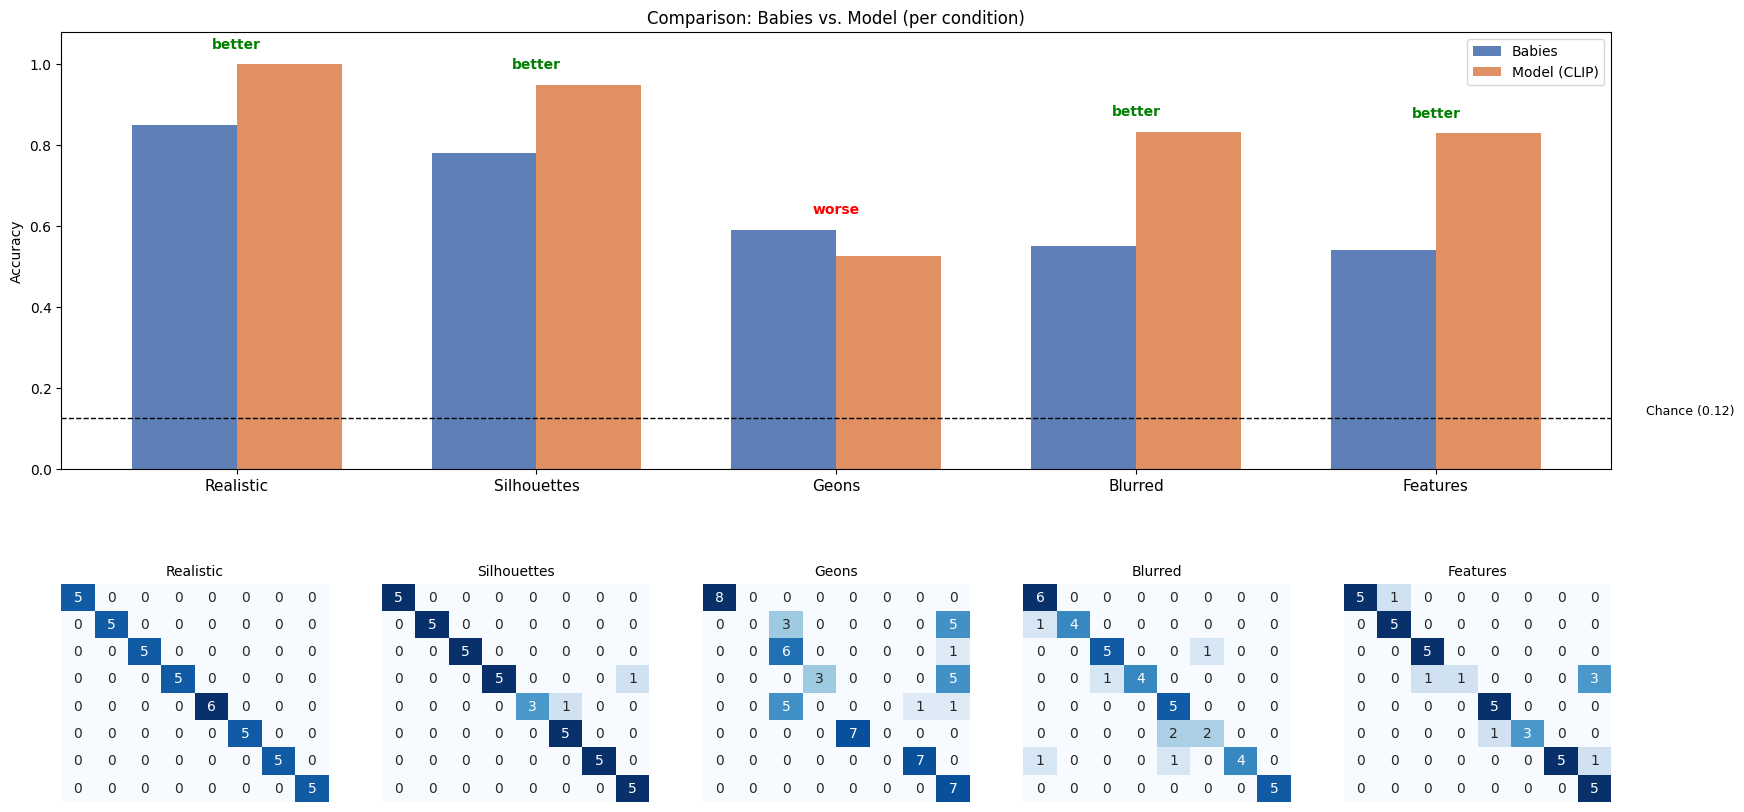

In [34]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RESULT_JSON = Path("/content/modelvsbaby_eval_results/modelvsbaby_clip_results.json")

if RESULT_JSON.exists():
    data = json.loads(RESULT_JSON.read_text())
    model_accs = {
        cond: data[cond]["accuracy"] if data[cond]["accuracy"] is not None else np.nan
        for cond in ["realistic","features","blurred","geons","silhouettes"]
    }
    cms = {cond: np.array(data[cond]["confusion_matrix"]) if data[cond]["confusion_matrix"] is not None else None
           for cond in ["realistic","features","blurred","geons","silhouettes"]}
else:
    model_accs = {
        "realistic": 1.0000,
        "features": 0.8293,
        "blurred":  0.8333,
        "geons":    0.5254,
        "silhouettes": 0.9500
    }
    cms = {k: None for k in model_accs.keys()}

baby_accs = {
    "realistic":   0.85,
    "silhouettes": 0.78,
    "geons":       0.59,
    "blurred":     0.55,
    "features":    0.54
}

# Ordering for plot
conds = ["realistic", "silhouettes", "geons", "blurred", "features"]
labels_pretty = ["Realistic","Silhouettes","Geons","Blurred","Features"]

model_vals = np.array([model_accs[c] for c in conds])
baby_vals  = np.array([baby_accs[c]  for c in conds])

delta = 0.05
comparison = []
for m, b in zip(model_vals, baby_vals):
    if np.isnan(m) or np.isnan(b):
        comparison.append("N/A")
    elif m > b + delta:
        comparison.append("better")
    elif m < b - delta:
        comparison.append("worse")
    else:
        comparison.append("similar")


plt.rcParams.update({'font.size': 10})
fig = plt.figure(figsize=(20,10))
gs = fig.add_gridspec(2, 5, height_ratios=[2,1], width_ratios=[1,1,1,1,1], hspace=0.35)

ax_main = fig.add_subplot(gs[0,:])
x = np.arange(len(conds))
width = 0.35
ax_main.bar(x - width/2, baby_vals, width, label='Babies', color='#4C72B0', alpha=0.9)
ax_main.bar(x + width/2, model_vals, width, label='Model (CLIP)', color='#DD8452', alpha=0.9)

for i, (mv, bv, comp) in enumerate(zip(model_vals, baby_vals, comparison)):
    y = max(mv, bv)
    txt = comp
    ax_main.text(i, y + 0.04, txt, ha='center', fontsize=10, fontweight='bold',
                 color=('green' if txt=='better' else 'red' if txt=='worse' else 'gray'))

ax_main.set_xticks(x)
ax_main.set_xticklabels(labels_pretty, fontsize=11)
ax_main.set_ylabel("Accuracy")
ax_main.set_ylim(0, 1.08)
ax_main.set_title("Comparison: Babies vs. Model (per condition)")
ax_main.legend(loc='upper right')

chance = 1.0/8.0
ax_main.axhline(chance, color='k', linestyle='--', linewidth=1)
ax_main.text(len(conds)-0.3, chance+0.01, f"Chance ({chance:.2f})", fontsize=9)

for i, cond in enumerate(conds):
    ax_cm = fig.add_subplot(gs[1, i])
    cm = cms.get(cond, None)
    if cm is None:
        ax_cm.text(0.5, 0.5, "No\nconfusion\nmatrix", ha='center', va='center', fontsize=10)
        ax_cm.set_xticks([])
        ax_cm.set_yticks([])
    else:
        n = cm.shape[0]
        sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax_cm,
                    xticklabels=False, yticklabels=False, cmap='Blues')
    ax_cm.set_title(labels_pretty[i], fontsize=10)

plt.tight_layout()
plt.show()

In [35]:
print("Per-condition summary (model vs babies):")
for cond, lab in zip(conds, labels_pretty):
    m = model_accs[cond]
    b = baby_accs[cond]
    comp = comparison[conds.index(cond)]
    print(f" {lab:12s} | Model = {m:0.3f} | Babies = {b:0.3f} | -> {comp}")

# Save figure
out_path = Path("/content/model_vs_baby_comparison.png")
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"\nSaved comparison figure to {out_path}")


Per-condition summary (model vs babies):
 Realistic    | Model = 1.000 | Babies = 0.850 | -> better
 Silhouettes  | Model = 0.950 | Babies = 0.780 | -> better
 Geons        | Model = 0.525 | Babies = 0.590 | -> worse
 Blurred      | Model = 0.833 | Babies = 0.550 | -> better
 Features     | Model = 0.829 | Babies = 0.540 | -> better

Saved comparison figure to /content/model_vs_baby_comparison.png


Conditions where our model is better than babies

Silhouettes (95%)

Our model performs much higher than babies. Babies do not perform near-perfectly on silhouette images, the model’s strong performance suggests robust shape recognition without texture cues, unlike toddlers who rely more on specific visual features.

Features (83%)

Babies usually struggle with “features” (isolated local features without whole-object structure).Our model is substantially better, likely because CLIP-like models memorize local discriminative cues that babies cannot use.

Blurred (83%)

Babies’ blurred accuracy is moderate but not this high.
Our model again outperforms babies, likely due to strong global embeddings that tolerate texture loss.

Conditions where Our model is similar to babies

Realistic (100%)

Both babies and the model perform the best on realistic stimuli. Babies do not reach 100%, but they are clearly best-in-class here. So the pattern matches: both rank this as easiest.

Conditions where Our model is worse than babies

Geons (0.53)

This is the only major weakness relative to babies. Babies still struggle with geons, but not as drastically and importantly, the pattern in the Fig. 3A shows babies perform better on geons than on features.

Our model does the opposite: It performs worse on geons than on features, reversing the baby pattern.